# TabICL (classification) Hyperparameter Tuning Using Mother

This notebook mirrors the molecular classification workflow used in the Lasso example, adapted to `TabICLClassifierMother`.

It covers:
1. Molecular preprocessing from `smiles`
2. Feature generation
3. Group-aware cross-validation with Tanimoto clusters
4. Training a `TabICLClassifierMother` pipeline
5. Hyperparameter optimization with `MotherTuner`

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import logging
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import metrics
from sklearn import pipeline as sklearn_pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GroupKFold, KFold

import mother.ml as ml
import mother.optimization as opt
from mother import cv as cv_module
from mother import feature_generation as fg
import mother.pipeline_utils as mother_takes_care
from mother.ml.models.m_tabicl import TabICLClassifierMother
from mother.preprocessing import SmilesToMolTransformer, StandardizerTransformer

%matplotlib inline
logging.basicConfig(level=logging.INFO)
warnings.filterwarnings("ignore")

In [2]:
ml.get_available_algorithms()

INFO:mother.ml:Loaded 13 model classes: LassoClassifierBinaryMother, LassoClassifierMulticlassMother, LassoRegressorMother, CatboostClassifierMother, CatboostGaussianProcessRegressorMother, CatboostRankerMother, CatboostRegressorMother, RandomForestClassifierMother, RandomForestRegressorMother, TabPFNClassifierMother, TabPFNRegressorMother, TabICLClassifierMother, TabICLRegressorMother


['lasso', 'catboost', 'randomforest', 'tabpfn', 'tabicl']

In [3]:
print(*ml.get_supported_models(), sep=" -- ")
print(ml.describe_model("TabICLClassifierMother"))

LassoClassifierBinaryMother -- LassoClassifierMulticlassMother -- LassoRegressorMother -- CatboostClassifierMother -- CatboostGaussianProcessRegressorMother -- CatboostRankerMother -- CatboostRegressorMother -- RandomForestClassifierMother -- RandomForestRegressorMother -- TabPFNClassifierMother -- TabPFNRegressorMother -- TabICLClassifierMother -- TabICLRegressorMother
## TabICLClassifierMother

Mother-compatible wrapper around :class:`tabicl.TabICLClassifier`.

Combines TabICL's in-context-learning classifier with the MotherML
hyperparameter management API (Optuna-ready, sklearn-compatible).

Parameters
----------
n_estimators : int, default 8
    Number of ensemble estimators.  Higher values improve stability at
    the cost of inference time.
softmax_temperature : float, default 0.9
    Temperature applied to logits before the softmax.  Values below 1.0
    sharpen the distribution; values above 1.0 soften it.
average_logits : bool, default True
    If ``True``, logits are averaged

## Import Data
Load molecular structures and binary target (`p_np`).

In [4]:
input_file: Path = Path("../compounds_class_1.csv")
data: pd.DataFrame = pd.read_csv(input_file, sep=",")
data = data[["name", "smiles", "p_np"]].dropna()
data.head()

,name,smiles,p_np
0,"""1,1,1-Trifluro-2-chloroethane""",FC(F)(F)CCl,1
1,111-trichloroethane,CC(Cl)(Cl)Cl,1
2,111-trifluoro-2-chloroethane,FC(F)(F)CCl,1
3,2-Methylpentane,CCCC(C)C,1
4,3-methylhexane,CCCC(C)CC,1


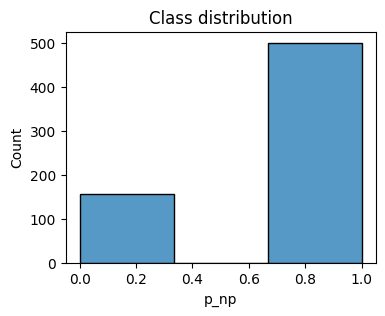

Rows: 657


In [6]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
sns.histplot(data=data, x="p_np", bins=3, ax=ax)
ax.set_title("Class distribution")
plt.show()
print(f"Rows: {len(data)}")

## Preprocessing
Standardize molecular structures and convert SMILES into molecule objects.

In [ ]:
preprocessor = sklearn_pipeline.Pipeline(
    [
        (
            "smiles_standardizer",
            StandardizerTransformer(flags=["STANDARDIZE", "NEUTRALIZE", "DESALT"]),
        ),
        ("smiles_to_mol", SmilesToMolTransformer()),
    ],
    memory=None,
).set_output(transform="pandas")

structure_data: pd.Series = data["smiles"]
mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)  # type: ignore

print(mol_data.shape)
mol_data.dropna(subset="Molecule", inplace=True, axis=0)
print(mol_data.shape)

INFO:mother.preprocessing.core:Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[11:18:41] Initializing Normalizer
[11:18:41] Initializing MetalDisconnector
[11:18:41] Initializing Normalizer
ERROR:mother.preprocessing.core:Catched exception from RDKit during standardization of SMILES with INDEX: 384


(657, 1)
(657, 1)


## Feature Generation
Build a molecular feature matrix from fingerprints and descriptors.

In [8]:
feature_generator = sklearn_pipeline.FeatureUnion(
    transformer_list=[
        ("maccs", fg.MaccsFingerprints()),
        ("morgan", fg.MorganFingerprints()),
        ("desc", fg.ChemicalDescriptors()),
    ],
).set_output(transform="pandas")

features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"])
target = data.loc[mol_data.index, "p_np"].reset_index(drop=True)
features = features.reset_index(drop=True)
features.head()

INFO:mother.feature_generation.core:Calculating MACCS fingerprints
INFO:mother.feature_generation.core:Calculating MorganFP fingerprints using parameters: {'radius': 2, 'fpSize': 1024, 'includeChirality': False}
INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'


,maccs__maccs_0,maccs__maccs_1,maccs__maccs_2,maccs__maccs_3,maccs__maccs_4,maccs__maccs_5,maccs__maccs_6,maccs__maccs_7,maccs__maccs_8,maccs__maccs_9,...,desc__fr_sulfide,desc__fr_sulfonamd,desc__fr_sulfone,desc__fr_term_acetylene,desc__fr_tetrazole,desc__fr_thiazole,desc__fr_thiocyan,desc__fr_thiophene,desc__fr_unbrch_alkane,desc__fr_urea
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Grouping for Cross-Validation
Group molecules by Tanimoto similarity to avoid information leakage across folds.

In [21]:
groups_engine = cv_module.TanimotoGroupingFromMols(similarity_threshold=0.3)
groups_raw: pd.DataFrame = groups_engine.set_output(transform="pandas").fit_transform(mol_data["Molecule"])  # type: ignore
groups = groups_raw.reset_index(drop=True)
cv = GroupKFold(
    n_splits=2
)  # For demonstration purposes, we use 2 splits. In practice, you may want to use more splits.

print(f"{groups['tanimoto-group'].nunique()} groups found")

INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.cv.cv_methods:Applying clustering with Tanimoto similarity: 0.3
INFO:mother.cv.cv_methods:Found: 274 clusters


274 groups found


## Model Training
Create a pipeline with feature selection and `TabICLClassifierMother`.

In [26]:
model_settings = {
    "feature_selection_flags": ["DROP_CORRELATED", "DROP_CONSTANT", "DROP_DUPLICATES", "DROP_UNIMPORTANT"],
    "feature_selection_threshold": 1e-5,
    "correlation_threshold": 0.9,
    "algorithm": "catboost",
    "target_type": "single_target",
    "model_type": "classification_binary",
    "feature_selection_type": "permutation",
}
pipeline_settings = {
    "remainder": "drop",
    "verbose_feature_names_out": False,
}

model = ml.PipelineWithHyperparameterRooting(
    [
        (
            "feature_selector",
            mother_takes_care.get_feature_selection_pipeline(
                settings=model_settings,
                pipeline_settings=pipeline_settings,
                cv=KFold(n_splits=2, shuffle=True, random_state=42),
            ).set_output(transform="pandas"),
        ),
        (
            "ml_model",
            TabICLClassifierMother(n_estimators=4, softmax_temperature=0.9, average_logits=True),
        ),
    ]
)

model.fit(features, target)
targets_pred = model.predict(features)
pred_df = pd.concat((target, pd.Series(targets_pred, name="p_np_pred")), axis=1)
pred_df.head()

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.pipeline_utils:Setting up permutation importance feature selection


INFO:mother.ml.estimators:Start permutation feature importance calculation for selection
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Finished permutation feature importance calculation for selection
INFO:mother.ml.estimators:Initialized permutation feature importance estimator


,p_np,p_np_pred
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


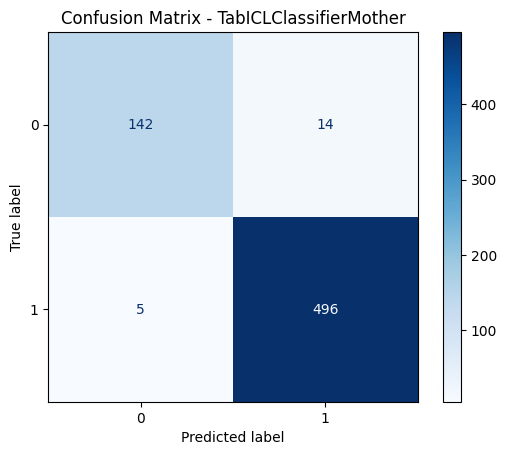

In [27]:
y_true = target
y_pred = targets_pred
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - TabICLClassifierMother")
plt.show()

In [28]:
def calc_metrics(labels_test, test_probs, threshold=0.5):
    scores = [1 if x >= threshold else 0 for x in test_probs]
    auc = metrics.roc_auc_score(labels_test, test_probs)
    kappa = metrics.cohen_kappa_score(labels_test, scores)
    confusion = metrics.confusion_matrix(labels_test, scores, labels=list(set(labels_test)))
    logging.info("thresh: %.2f, kappa: %.3f, AUC: %.3f" % (threshold, kappa, auc))
    logging.info(f"\n{confusion}")
    logging.info(f"\n{metrics.classification_report(labels_test, scores)}")


test_probs = model.predict_proba(features)[:, 1]
calc_metrics(target.to_numpy(), test_probs, threshold=0.5)

INFO:root:thresh: 0.50, kappa: 0.919, AUC: 0.994
INFO:root:
[[142  14]
 [  5 496]]
INFO:root:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       156
           1       0.97      0.99      0.98       501

    accuracy                           0.97       657
   macro avg       0.97      0.95      0.96       657
weighted avg       0.97      0.97      0.97       657



## Cross-Validation
Evaluate model performance with grouped CV.

In [29]:
cross_val_scores: pd.DataFrame = mother_takes_care.mother_cv(
    estimator=model,
    X=features,
    y=target,
    groups=groups["tanimoto-group"],  # type: ignore
    cv=cv,
)
cross_val_scores

INFO:mother.pipeline_utils:Starting cross validation...


INFO:mother.ml.estimators:Start permutation feature importance calculation for selection
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Finished permutation feature importance calculation for selection
INFO:mother.ml.estimators:Initialized permutation feature importance estimator
INFO:mother.ml.estimators:Start permutation feature importance calculation for selection
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Finished permutation feature importance calculation for selection
INFO:mother.ml.estimators:Initialized permutation feature importance estimator
INFO:mother.pipeline_utils:Cross validation completed


,pred_p_np,pred_proba_0,pred_proba_1,pred_total_uncertainty,p_np,cv_group,iteration,test_index
0,1,0.072936,0.927064,0.261169,1,0,0,0
1,1,0.034276,0.965724,0.149306,1,1,0,1
2,1,0.072936,0.927064,0.261169,1,0,0,2
3,1,0.031422,0.968578,0.139651,1,2,0,3
4,1,0.032176,0.967824,0.142228,1,2,0,4
...,...,...,...,...,...,...,...,...
652,1,0.074138,0.925862,0.264214,1,270,1,652
653,1,0.022335,0.977665,0.106992,1,271,0,653
654,1,0.054191,0.945809,0.210677,1,263,1,654
655,1,0.017298,0.982702,0.087328,1,272,0,655


## Hyperparameter Optimization
Tune the full pipeline with Optuna via `MotherTuner`.

In [30]:
tuner = opt.MotherTuner(
    n_threads_optuna=2,
    scorer="f1",
    n_trials_optuna=2,
    n_startup_trials=1,
)

model_tuned = tuner.optimize(
    model,
    features,
    target,
    cv,
    hyperparameter_space_function=model.get_hyperparameter_space,
    default_parameters=model.default_parameters(),
    groups=groups["tanimoto-group"],
)

print("Best params:", tuner.study.best_params)
print("Best score:", tuner.study.best_value)

INFO:mother.optimization.core:Setting up Optuna to optimize hyperparameters with direction: 2
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-c407c082-9dff-4e11-8569-7f311e84c36e
INFO:mother.optimization.core:Running hyperparameter optimization with 2 trials
INFO:mother.ml.models.m_tabicl:Suggested TabICL parameters in trial 0: {'n_estimators': 8, 'softmax_temperature': 0.9, 'average_logits': True}
/home/ec2-user/coding/MotherML/.venv/lib/python3.13/site-packages/tabicl/_sklearn/sklearn_utils.py:105: UserWarning: X has feature names, but TabICLClassifierMother was fitted without feature names
  warnings.warn(f"X has feature names, but {estimator.__class__.__name__} was fitted without feature names")
/home/ec2-user/coding/MotherML/.venv/lib/python3.13/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/home/ec2-user/coding/MotherML/.venv/lib/python3.13/site-packages/tab

{'feature_selector__feature_selector__importance_selector__threshold': 2.2250738585072014e-308, 'ml_model__n_estimators': 8, 'ml_model__softmax_temperature': 0.9, 'ml_model__average_logits': True}


INFO:mother.ml.estimators:Start permutation feature importance calculation for selection
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Finished permutation feature importance calculation for selection
INFO:mother.ml.estimators:Initialized permutation feature importance estimator
INFO:mother.optimization.core:Training completed


Best params: {'feature_selector__feature_selector__importance_selector__threshold': 2.2250738585072014e-308, 'ml_model__n_estimators': 8, 'ml_model__softmax_temperature': 0.9, 'ml_model__average_logits': True}
Best score: 0.9156357722173046


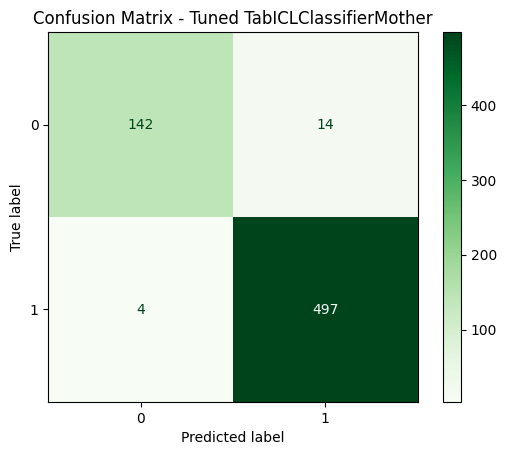

In [31]:
targets_pred_tuned = model_tuned.predict(features)
cm_tuned = confusion_matrix(target, targets_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned)
disp_tuned.plot(cmap="Greens")
plt.title("Confusion Matrix - Tuned TabICLClassifierMother")
plt.show()